In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("social_network_dataset.csv")

In [3]:
print(df.head())
print(df.info())

    user_1   user_2  messages  likes
0  user_95  user_58        45     99
1  user_44   user_7        29     34
2  user_26  user_80        14     64
3  user_26  user_78        36     88
4  user_94  user_88         6     52
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494 entries, 0 to 493
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   user_1    494 non-null    object
 1   user_2    494 non-null    object
 2   messages  494 non-null    int64 
 3   likes     494 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 15.6+ KB
None


In [4]:
df = df.dropna()
df = df.drop_duplicates()

**GIRVAN-NEWMAN (Community Detection)**

In [5]:
G = nx.from_pandas_edgelist(df, 'user_1', 'user_2') #build graph

Build community

In [6]:
from networkx.algorithms.community import girvan_newman

communities = girvan_newman(G)
first_level = next(communities)

print("Communities:")
for c in first_level:
    print(list(c))

Communities:
['user_17', 'user_86', 'user_25', 'user_66', 'user_21', 'user_24', 'user_63', 'user_37', 'user_84', 'user_52', 'user_3', 'user_80', 'user_62', 'user_1', 'user_22', 'user_81', 'user_56', 'user_88', 'user_27', 'user_49', 'user_19', 'user_77', 'user_73', 'user_18', 'user_5', 'user_6', 'user_53', 'user_76', 'user_64', 'user_44', 'user_50', 'user_55', 'user_13', 'user_78', 'user_91', 'user_10', 'user_65', 'user_89', 'user_93', 'user_12', 'user_87', 'user_40', 'user_36', 'user_11', 'user_42', 'user_51', 'user_26', 'user_31', 'user_100', 'user_83', 'user_28', 'user_38', 'user_75', 'user_95', 'user_72', 'user_58', 'user_69', 'user_4', 'user_30', 'user_35', 'user_70', 'user_15', 'user_47', 'user_99', 'user_46', 'user_9', 'user_92', 'user_7', 'user_39', 'user_20', 'user_59', 'user_85', 'user_71', 'user_68', 'user_82', 'user_32', 'user_14', 'user_96', 'user_41', 'user_61', 'user_97', 'user_23', 'user_45', 'user_90', 'user_48', 'user_67', 'user_74', 'user_29', 'user_94', 'user_79', 'u

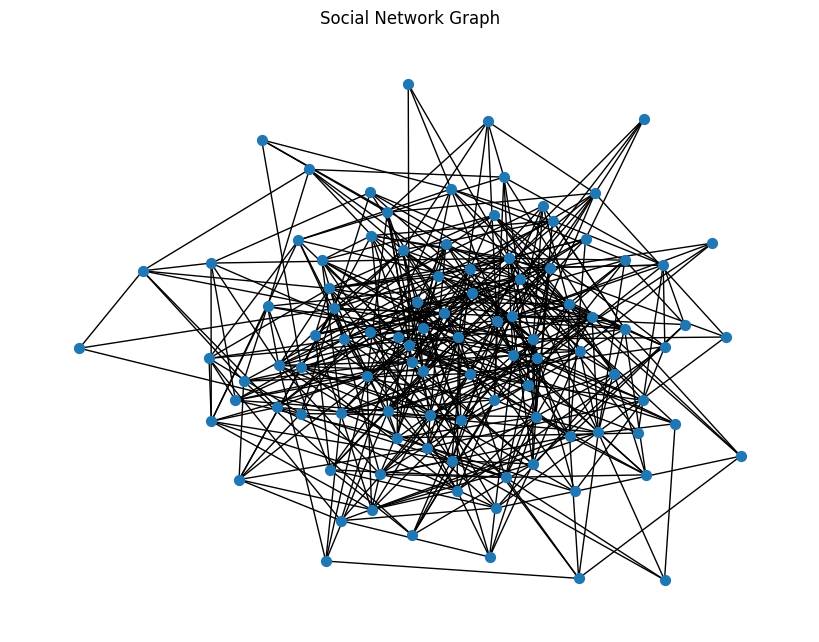

In [12]:
plt.figure(figsize=(8,6))
nx.draw(G, node_size=50)
plt.title("Social Network Graph")
plt.show()

**K Means**

In [8]:
features = df[['messages','likes']]

In [9]:
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(features)

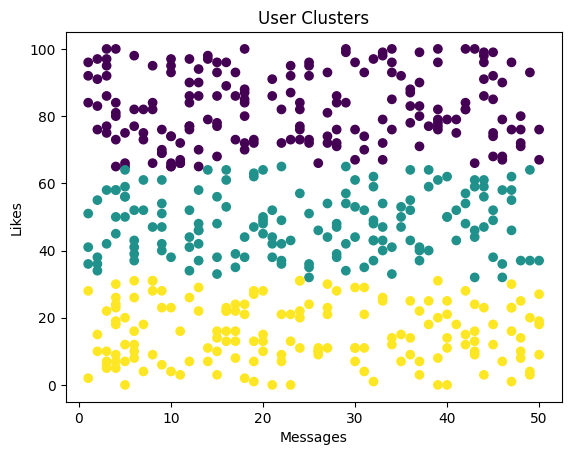

In [14]:
plt.scatter(x=df['messages'], y=df['likes'], c=df['cluster'])

plt.xlabel("Messages")
plt.ylabel("Likes")
plt.title("User Clusters")

plt.show()